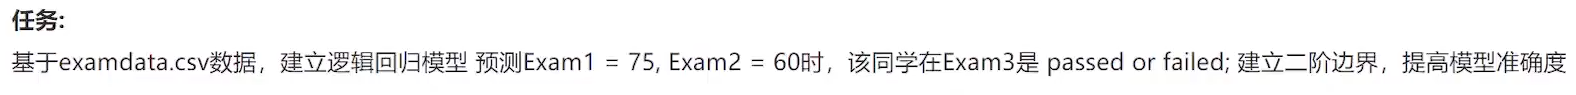

In [2]:
# load the data
import pandas as pd
import numpy as np
data = pd.read_csv('examdata.csv')
data.head()

,Exam1,Exam2,Pass
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


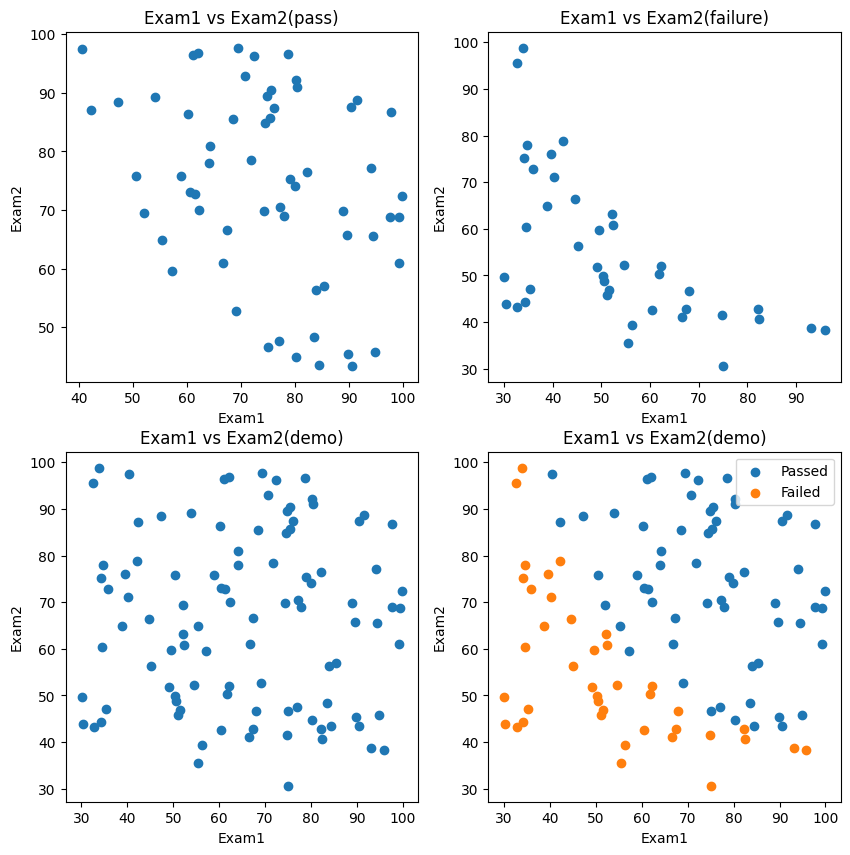

In [3]:
# visualize the data
from matplotlib import pyplot as plt
fig = plt.figure(figsize=(10,10))

# add label mask
mask = data.loc[:,'Pass'] == 1

fig1 = plt.subplot(221)
plt.scatter(data.loc[:,'Exam1'][mask],data.loc[:,'Exam2'][mask])
plt.title('Exam1 vs Exam2(pass)')
plt.xlabel('Exam1')
plt.ylabel('Exam2')

fig2 = plt.subplot(222)
plt.scatter(data.loc[:,'Exam1'][~mask],data.loc[:,'Exam2'][~mask])
plt.title('Exam1 vs Exam2(failure)')
plt.xlabel('Exam1')
plt.ylabel('Exam2')

fig3 = plt.subplot(223)
plt.scatter(data.loc[:,'Exam1'],data.loc[:,'Exam2'])
plt.title('Exam1 vs Exam2(demo)')
plt.xlabel('Exam1')
plt.ylabel('Exam2')

fig4 = plt.subplot(224)
#新建两个图的实列，对其进行图例的标注
passed = plt.scatter(data.loc[:,'Exam1'][mask],data.loc[:,'Exam2'][mask])
failed = plt.scatter(data.loc[:,'Exam1'][~mask],data.loc[:,'Exam2'][~mask])
plt.title('Exam1 vs Exam2(demo)')
plt.xlabel('Exam1')
plt.ylabel('Exam2')
# 添加图例
plt.legend((passed, failed), ('Passed', 'Failed'))
plt.show()

In [4]:
# add label mask
mask = data.loc[:,'Pass'] == 1
print(mask)

0     False
1     False
2     False
3      True
4      True
      ...  
95     True
96     True
97     True
98     True
99     True
Name: Pass, Length: 100, dtype: bool


In [5]:
#dafine X,y
X = data.drop('Pass', axis=1)
y = data.loc[:,'Pass']
X1 = data.loc[:,'Exam1']
X2 = data.loc[:,'Exam2']
X2.head()

0    78.024693
1    43.894998
2    72.902198
3    86.308552
4    75.344376
Name: Exam2, dtype: float64

In [6]:
print(X.shape,y.shape)
print(type(X),type(y),type(X1),type(X2))

(100, 2) (100,)
<class 'pandas.DataFrame'> <class 'pandas.Series'> <class 'pandas.Series'> <class 'pandas.Series'>


In [7]:
# establish the model and train it
from sklearn.linear_model import LogisticRegression
LogicR= LogisticRegression()
# 训练模型使用data.values，其数据类型换为numpy，在后面进行模型预测的时候不会出现类型警告
# 进行模型训练，
# 输入:1、每位同学的两次考试成绩，2、每位同学第三次考试成绩是否合格
# 输出：预测模型，根据输入的数据得到一个预测模型
LogicR.fit(X.values,y.values)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [8]:
# show the predicted result and its accuracy
# 将每名考生的两次考试成绩作为输入，在模型中得到预测的第三次考试是否通过，与已知的第三次考试结果进行比较，判断该模型的预测准确率
y_predict = LogicR.predict(X.values)
print(y_predict)

[0 0 0 1 1 0 1 0 1 1 1 0 1 1 0 1 0 0 1 1 0 1 0 0 1 1 1 1 0 0 1 1 0 0 0 0 1
 1 0 0 1 0 1 1 0 0 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 0 0 0 0 0 1 0 1 1 0 1 1 1
 1 1 1 1 0 1 1 1 1 0 1 1 0 1 1 0 1 1 0 1 1 1 1 1 0 1]


In [9]:
from sklearn.metrics import accuracy_score
# 将已知的结果与预测的结果进行比较，获得预测准确率
accuracy = accuracy_score(y,y_predict)
print(accuracy)

0.89


In [10]:
# exam1 = 70, exam2 = 65
# 对一个新数据进行预测其结果
y_test = LogicR.predict([[70,65]])
print('passed' if y_test ==1 else 'failed')

passed


In [11]:
# 逻辑回归中一次线性分界线的参数X1，X2的系数
LogicR.coef_

array([[0.20535491, 0.2005838 ]])

In [12]:
# 逻辑回归中一次线性分界线的截距
LogicR.intercept_

array([-25.05219314])

In [13]:
theta0 = LogicR.intercept_
theta1,theta2 = LogicR.coef_[0][0],LogicR.coef_[0][1]
print(theta0,theta1,theta2)

[-25.05219314] 0.20535491217790397 0.2005838039546906


In [14]:
# 利用现有的X1点，画出预测模型的决策边界
X2_new = -(theta0 + theta1*X1)/theta2
print(X2_new)

0     89.449169
1     93.889277
2     88.196312
3     63.282281
4     43.983773
        ...    
95    39.421346
96    81.629448
97    23.219064
98    68.240049
99    48.341870
Name: Exam1, Length: 100, dtype: float64


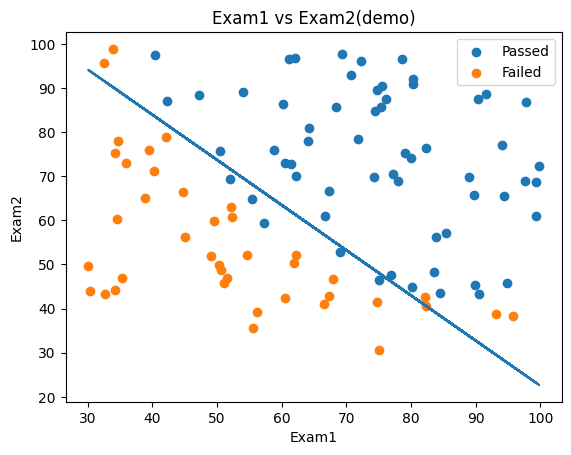

In [15]:
fig5 = plt.figure()
passed = plt.scatter(data.loc[:,'Exam1'][mask],data.loc[:,'Exam2'][mask])
failed = plt.scatter(data.loc[:,'Exam1'][~mask],data.loc[:,'Exam2'][~mask])
plt.plot(X1,X2_new)
plt.title('Exam1 vs Exam2(demo)')
plt.xlabel('Exam1')
plt.ylabel('Exam2')
# 添加图例
plt.legend((passed, failed), ('Passed', 'Failed'))
plt.show()

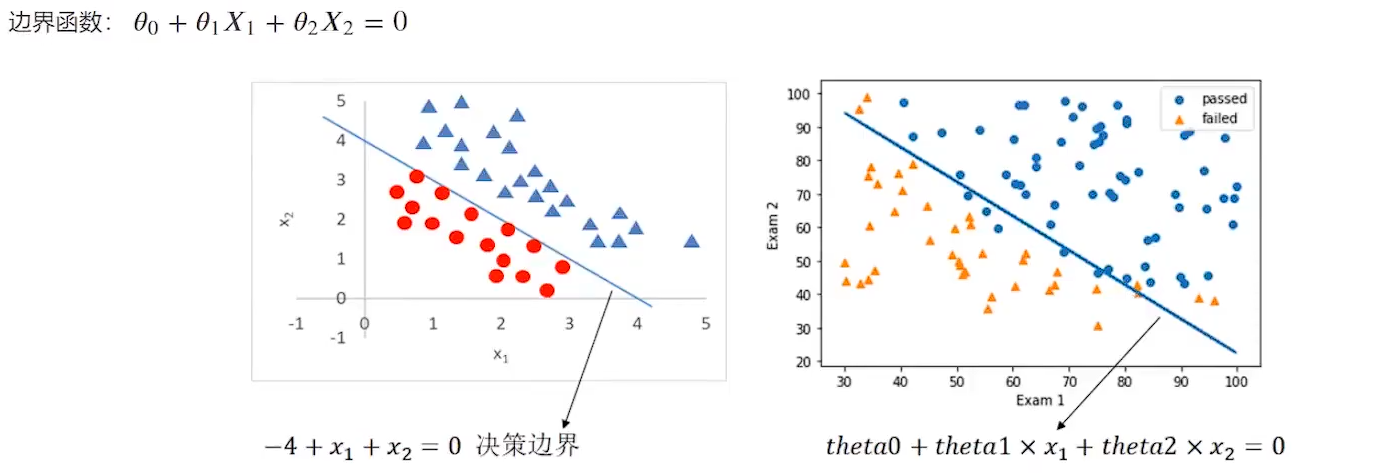

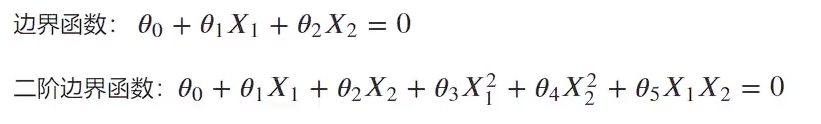

In [16]:
# create new data
X1_2 = X1 * X1
X2_2 = X2 * X2
X1_X2 = X1 *X2


In [17]:
X_new = {'X1':X1,'X2':X2,'X1_2':X1_2,'X2_2':X2_2,'X1_X2':X1_X2}
X_new = pd.DataFrame(X_new)
print(X_new)

           X1         X2         X1_2         X2_2        X1_X2
0   34.623660  78.024693  1198.797805  6087.852690  2701.500406
1   30.286711  43.894998   917.284849  1926.770807  1329.435094
2   35.847409  72.902198  1285.036716  5314.730478  2613.354893
3   60.182599  86.308552  3621.945269  7449.166166  5194.273015
4   79.032736  75.344376  6246.173368  5676.775061  5954.672216
..        ...        ...          ...          ...          ...
95  83.489163  48.380286  6970.440295  2340.652054  4039.229555
96  42.261701  87.103851  1786.051355  7587.080849  3681.156888
97  99.315009  68.775409  9863.470975  4730.056948  6830.430397
98  55.340018  64.931938  3062.517544  4216.156574  3593.334590
99  74.775893  89.529813  5591.434174  8015.587398  6694.671710

[100 rows x 5 columns]


In [18]:
LogicR2 = LogisticRegression(max_iter=1000)
LogicR2.fit(X_new.values,y.values)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [19]:
y2_predict = LogicR2.predict(X_new.values)
accuracy2 = accuracy_score(y,y2_predict)
print(accuracy2)

1.0


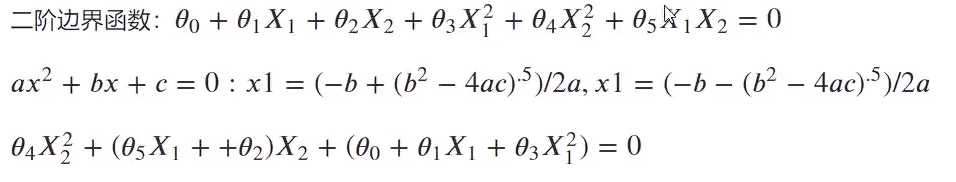

In [20]:
#画出决策边界
LogicR2.coef_

array([[ 0.0020574 , -0.00065056, -0.02024934, -0.01999267,  0.17598018]])

In [21]:
theta0 = LogicR2.intercept_
theta1,theta2,theta3,theta4,theta5 = LogicR2.coef_[0][0],LogicR2.coef_[0][1],LogicR2.coef_[0][2],LogicR2.coef_[0][3],LogicR2.coef_[0][4]
print(theta0,theta1,theta2,theta3,theta4,theta5)

[-451.35745849] 0.002057401027454806 -0.0006505649717466136 -0.020249340074011326 -0.019992671376771753 0.17598018266087564


In [24]:
# 对X1的值进行大小排序，这样画出来的边界曲线才是一条光滑的曲线
X1_new  = X1.sort_values()
a = theta4
b = theta5 * X1_new + theta2
c = theta0 + theta1 * X1_new + theta3 * X1_new * X1_new
print(a,b,c)
# 求解每一个X1点对应的决策边界上的X2的新值，也就是画出决策边界线
X2_new_boundary = (-b + np.sqrt(b * b - 4 * a * c))/(2 * a)

-0.019992671376771753 63     5.289107
1      5.329210
57     5.732291
70     5.757920
36     5.967805
        ...    
56    17.183046
47    17.205213
51    17.469347
97    17.476823
75    17.567074
Name: Exam1, Length: 100, dtype: float64 63   -469.591559
1    -469.869559
57   -472.780532
70   -472.972800
36   -474.579710
         ...    
56   -644.227334
47   -644.725529
51   -650.711162
97   -650.881906
75   -652.948920
Name: Exam1, Length: 100, dtype: float64


D:\study\code\python\study\DailyWork\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


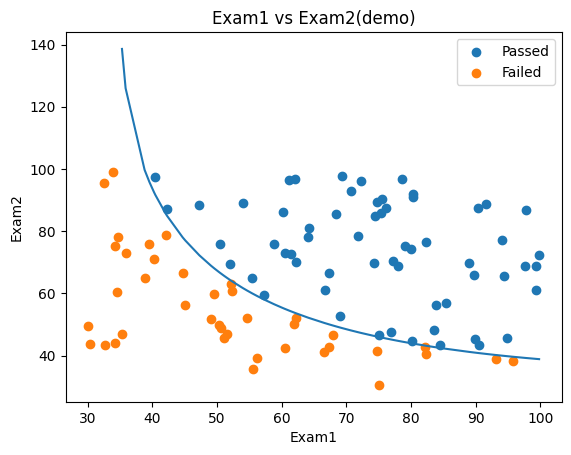

In [25]:
fig6 = plt.figure()
passed = plt.scatter(data.loc[:,'Exam1'][mask],data.loc[:,'Exam2'][mask])
failed = plt.scatter(data.loc[:,'Exam1'][~mask],data.loc[:,'Exam2'][~mask])
plt.plot(X1_new,X2_new_boundary)
plt.title('Exam1 vs Exam2(demo)')
plt.xlabel('Exam1')
plt.ylabel('Exam2')
# 添加图例
plt.legend((passed, failed), ('Passed', 'Failed'))
plt.show()